In [1]:
!pip3 install scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 5.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 5.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 5.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 5.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 4.2 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [matplotlib]3 [matplotlib]n]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


Matplotlib is building the font cache; this may take a moment.



  Logistic Regression
Accuracy : 0.9561
Precision: 0.9459
Recall   : 0.9859
F1-Score : 0.9655

  Random Forest
Accuracy : 0.9649
Precision: 0.9589
Recall   : 0.9859
F1-Score : 0.9722


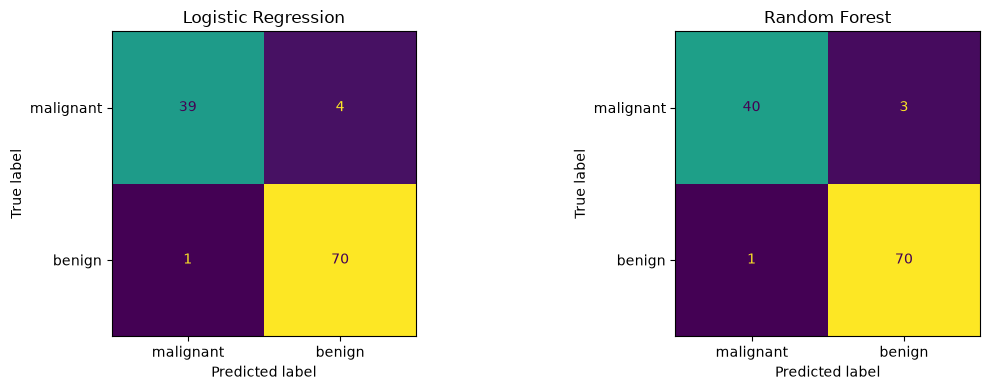

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=10000)
rf = RandomForestClassifier(random_state=42)
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

def evaluate(name, y_test, y_pred):
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")

evaluate("Logistic Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, name in zip(axes, [lr_pred, rf_pred], ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()

In [ ]:
# Model Comparison Summary
# 
# | Metric    | Logistic Regression | Random Forest |
# |-----------|---------------------|---------------|
# | Accuracy  | 0.9561              | 0.9649        |
# | Precision | 0.9459              | 0.9589        |
# | Recall    | 0.9859              | 0.9859        |
# | F1-Score  | 0.9655              | 0.9722        |
#
# Which model performed better and why?
# Random Forest outperformed Logistic Regression on all metrics
# except Recall (which was equal). Random Forest handles complex,
# non-linear relationships between features better, making it
# more effective on the Breast Cancer Wisconsin dataset which
# has 30 features with complex interactions.

print("Random Forest performed better overall.")
print("Higher accuracy (0.9649 vs 0.9561), precision (0.9589 vs 0.9459)")
print("and F1-Score (0.9722 vs 0.9655). Recall was equal (0.9859).")